# Customer Churn Prediction using Machine Learning

### Problem Statement

#### Customer churn occurs when customers stop using a company's service.

#### The objective of this project is to predict whether a customer will churn based on customer information and service usage patterns.

#### Several machine learning models were trained and compared to identify the best-performing model.

## Dataset Overview

### The dataset contains customer information such as:

#### - Demographics
#### - Service subscriptions
#### - Contract details
#### - Billing information

#### Target Variable:

#### - Churn = 1 (Customer Left)
#### - Churn = 0 (Customer Stayed)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold
)

from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

## Dataset Loading and Inspection

In [2]:
df = pd.read_csv('churn.csv')

pd.set_option('display.max_columns', None)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Data Cleaning and Preprocessing

In [6]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

df['Churn'] = df['Churn'].map({
    'Yes':1,
    'No':0
})

In [7]:
x = df.drop(
    ['Churn', 'customerID'],
    axis=1
)

y = df['Churn']

In [8]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.25,
    random_state=42
)

In [9]:
cat_cols = x_train.select_dtypes(include='object').columns

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

x_train_enc = encoder.fit_transform(x_train[cat_cols])
x_test_enc = encoder.transform(x_test[cat_cols])

#GET REAL FEATURE NAMES
feature_names = encoder.get_feature_names_out(cat_cols)

# converting to DataFrame properly
x_train_enc = pd.DataFrame(x_train_enc, columns=feature_names, index=x_train.index)
x_test_enc = pd.DataFrame(x_test_enc, columns=feature_names, index=x_test.index)

# removing original columns
x_train = x_train.drop(cat_cols, axis=1)
x_test = x_test.drop(cat_cols, axis=1)

# merging back
x_train = pd.concat([x_train, x_train_enc], axis=1)
x_test = pd.concat([x_test, x_test_enc], axis=1)

In [10]:
x_train = x_train.fillna(
    x_train.median(numeric_only=True)
)

x_test = x_test.fillna(
    x_train.median(numeric_only=True)
)

## Model Training and Hyperparameter Tuning

In [11]:
models = {
    "KNN": (KNeighborsClassifier(), {
        'n_neighbors': [3,5,7,9],
        'metric' : ['euclidean', 'manhattan', 'minkowski']
    }),

    "DecisionTree": (DecisionTreeClassifier(random_state = 42), {
        'max_depth': [3,5,10,None]
    }),

    "RandomForest": (RandomForestClassifier(random_state = 42), {
        'n_estimators': [50,100],
        'max_depth': [5,10,None]
    })
}

In [12]:
results = []

best_model = None
best_accuracy = 0

rf_model = None

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

for name, (model, params) in models.items():

    grid = GridSearchCV(
        estimator=model,
        param_grid=params,
        cv=cv,
        scoring='accuracy',
        n_jobs=-1
    )

    grid.fit(x_train, y_train)

    y_pred = grid.best_estimator_.predict(x_test)

    acc = accuracy_score(y_test, y_pred)

    results.append({
        'Model': name,
        'Best Parameters': grid.best_params_,
        'Accuracy': acc
    })

    if acc > best_accuracy:
        best_accuracy = acc
        best_model = grid.best_estimator_

    if name == "RandomForest":
        rf_model = grid.best_estimator_

    print(f"{name} best accuracy: {acc:.4f}")

KNN best accuracy: 0.7831
DecisionTree best accuracy: 0.7916
RandomForest best accuracy: 0.7933


## Model Comparison Results

In [13]:
result_df = pd.DataFrame(results)
result_df = result_df.sort_values(
    by='Accuracy',
    ascending=False
)

result_df

,Model,Best Parameters,Accuracy
2,RandomForest,"{'max_depth': 5, 'n_estimators': 50}",0.793299
1,DecisionTree,{'max_depth': 5},0.791596
0,KNN,"{'metric': 'manhattan', 'n_neighbors': 9}",0.783078


## Best Performing Model

#### After comparing all trained models, the model with the highest accuracy was selected as the final model.

In [14]:
best_row = result_df.iloc[0]

print(f"Best model found is {best_row['Model']}")

print("\nBest Parameters:")

for k, v in best_row['Best Parameters'].items():
    print(f"{k}: {v}")

print("\nAccuracy:")
print(best_row['Accuracy'])

Best model found is RandomForest

Best Parameters:
max_depth: 5
n_estimators: 50

Accuracy:
0.7932992617830777


## Feature Importance Analysis

#### Random Forest provides feature importance scores that indicate which variables contribute most to customer churn prediction.

In [15]:
feature_importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
36,Contract_Month-to-month,0.153236
1,tenure,0.148715
18,OnlineSecurity_No,0.100283
16,InternetService_Fiber optic,0.092790
3,TotalCharges,0.079580
43,PaymentMethod_Electronic check,0.064338
27,TechSupport_No,0.048719
38,Contract_Two year,0.047560
2,MonthlyCharges,0.036962
21,OnlineBackup_No,0.025088


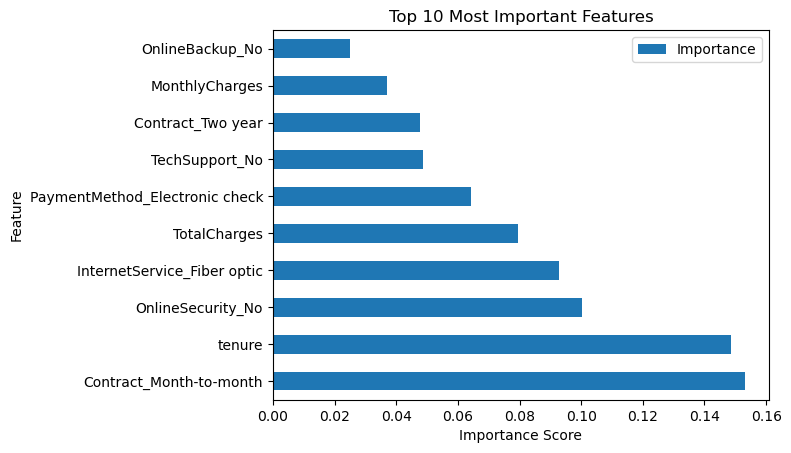

In [16]:
feature_importance.head(10).plot(
    x='Feature',
    y='Importance',
    kind='barh'
)

plt.title('Top 10 Most Important Features')
plt.xlabel('Importance Score')
plt.ylabel('Feature')

plt.show()

## Model Performance Comparison

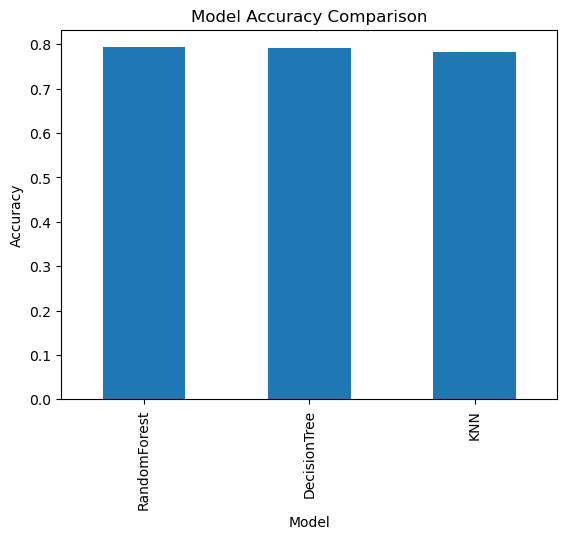

In [17]:
result_df.plot(
    x='Model',
    y='Accuracy',
    kind='bar',
    legend = False
)

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.show()

## Confusion Matrix

#### The confusion matrix provides a detailed breakdown of model predictions, showing correct and incorrect classifications.

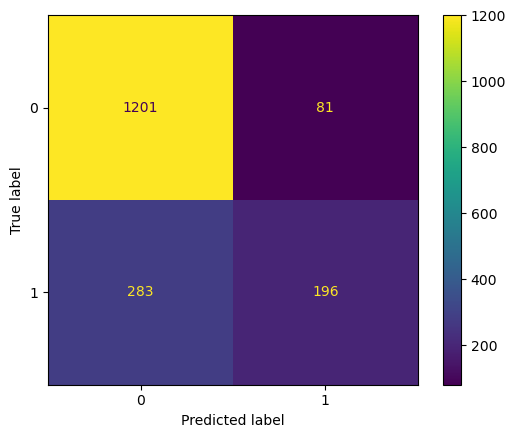

In [18]:
ConfusionMatrixDisplay.from_estimator(
    best_model,
    x_test,
    y_test
)

plt.show()

## Conclusion
#### Three machine learning algorithms were trained and evaluated using GridSearchCV.

#### Random Forest achieved the highest accuracy and was selected as the final model for customer churn prediction.

#### The project demonstrates:
#### - Data preprocessing
#### - One-hot encoding
#### - Missing value handling
#### - Hyperparameter tuning
#### - Model comparison
#### - Cross-validation 